# The Linear Integrate and Fire Neuron

Each real neuron adds up the synaptic inputs from its upstream neighbors and fires when this sum exceeds its threshold, after which it takes time to recover before it can fire again. The key quantity here is the transmembrane voltage $V\equiv V_{in}-V_{out}$.

<img src="../../ActionPotential.png" style="height:300px" />

We first build a model of a single neuron with a single synapse. The most simple, and most common, dynamical model views the cell membrane as a charge separator with fixed capacitance $C$ and leakage conductance $g_L$, with associated leak potential, $V_L$. The membrane also features a variable synaptic conductance $g_{syn}(t)$, with associated synaptic potential, $V_{syn}$. As these three components span the cell membrane they appear in parallel in the schematic below.

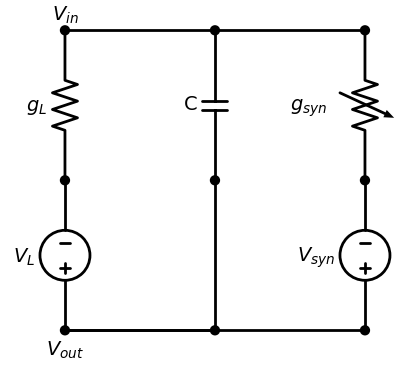

In [25]:
# single cell circuit model

import schemdraw
import schemdraw.elements as elm

with schemdraw.Drawing() as d:

    d += (gL := elm.Resistor().down().label('$g_L$').dot().label('$V_{in}$', 'right'))
    d += (VL := elm.SourceV().down().label('$V_L$').dot().label('$V_{out}$', 'left'))
    
    d += elm.Line().right().dot()
    d += elm.Line().up().dot()
    
    d += (C := elm.Capacitor().up().label('$C_m$').dot())
    d.push()   # save this spot
    d += elm.Line().tox(gL.end).dot()
    d.pop()   # resume
    d += elm.Line().right().dot()
    
    d += (Rvar := elm.ResistorVar().down().label('$g_{syn}$').dot())
    d += (Vsyn := elm.SourceV().down().label('$V_{syn}$').dot())
    
    d += elm.Line().tox(VL.start)
    

Applying the standard circuit laws results in the differential equation for $V\equiv V_{in}-V_{out}$,

\begin{equation}\label{eq:PV}
  C_mV'(t) = g_L(V_L-V(t)) + g_{syn}(t)(V_{syn}-V(t))
\end{equation}

while $g_{syn}$ is supposed to satisfy its own differential equation based on observations of neurotransmitter binding and firing of its presynaptic cell. In particular

\begin{equation}\label{eq:PS}
  \tau_{syn}g_{syn}'(t) = -g_{syn}(t) + w_{syn}\sum_n\delta(t-T_n)
\end{equation}

where the $T_n$ are the times at which the presynaptic cell fired, $w_{syn}$ is the synaptic weight, and $\tau_{syn}$ is the synaptic time constant. The delta function is defined by its integral

\begin{equation}\label{eq:delta}
  \int_a^b \delta(x)\,dx = \cases{ 1 & if $a<0<b$, \cr 0 & otherwise.}
\end{equation}

This is good enough for us for we will discretize time $t=[0,dt,2dt,...,Ndt]$ into intervals of length $dt$ and then integrate both (\ref{eq:PV}) and (\ref{eq:PS}) over each interval. Recalling the Fundamental Theorem of Calculus,

\begin{equation}\label{eq:iPS1}
  \int_{(j-1)dt}^{jdt} g_{syn}'(t)\,dt = g_{syn}(jdt) - g_{syn}((j-1)dt) 
\end{equation}

while the trapezoid rule reveals

\begin{equation}\label{eq:iPS2}
  \int_{(j-1)dt}^{jdt} (-g_{syn}(t)+ w_{syn}\sum_n\delta(t-T_n))\,dt =  - (g_{syn}((j-1)dt) + g_{syn}(jdt))dt/2
  + w_{syn}\#\{T_n:(j-1)dt < T_n < jdt\}
\end{equation}

That latter term is just the number of presynaptic spikes in the interval of interest. We will assume that $dt$ is so small that there is, at most, one such spike. With that let us abbreviate

\begin{equation}\label{eq:ktlang}
    g_{syn}^k \equiv g_{syn}(kt)
\end{equation}

and use this to arrive at the integrated form of (\ref{eq:PS}) 

\begin{equation}\label{eq:iPS3}
  \tau_{syn}(g_{syn}^j - g_{syn}^{j-1}) = - (g_{syn}^{j-1} + g_{syn}^j)dt/2 + w_{syn}\delta_{pre}^j
\end{equation}

where 

\begin{equation}\label{eq:Kdelta}
  \delta_{pre}^j = \cases{ 1 & if the presynaptic cell fired after $(j-1)dt$ and before $jdt$, \cr 0 & otherwise.}
\end{equation}

from here we can arrive at an explicit algebraic **marching scheme** that gets us from knowledge of $g_{syn}^{j-1}$ to knowledge of $g_{syn}^j$. In particular

\begin{equation}\label{eq:iPS4}
  \boxed{(\tau_{syn} + dt/2)g_{syn}^j = (\tau_{syn} - dt/2)g_{syn}^{j-1} + w_{syn}\delta_{pre}^j}
\end{equation}

We now apply identical reasoning and notation to our voltage equation, finding

\begin{equation}\label{eq:iPV1}
  \int_{(j-1)dt}^{jdt} V'(t)\,dt = V^j - V^{j-1} 
\end{equation}

and

\begin{equation}\label{eq:iPV2}
  \int_{(j-1)dt}^{jdt} (g_L(V_L-V(t)) + g_{syn}(t)(V_{syn}-V(t)))\,dt = g_L(V_Ldt - (V^{j-1} + V^j)dt/2)
    + g_{syn}^j(V_{syn}dt - (V^{j-1} + V^j)dt/2)
\end{equation}

and combined brings the voltage **marching scheme**

\begin{equation}\label{eq:iPV3}
  \boxed{(C_m + g_Ldt/2 + g_{syn}^jdt/2)V^j  = (C_m - g_Ldt/2 - g_{syn}^jdt/2)V^{j-1}  + g_LV_Ldt + g_{syn}^jV_{syn}dt}
\end{equation}

**until** $V^{j-1}$ hits threshold, upon which we set $V^j$ to $V_{res}$ for $t_{ref}$ milliseconds before returning to
(\ref{eq:iPV3}). We have coded this scheme below with "standard" model coefficients and a presynaptic spike every $P$ milliseconds.

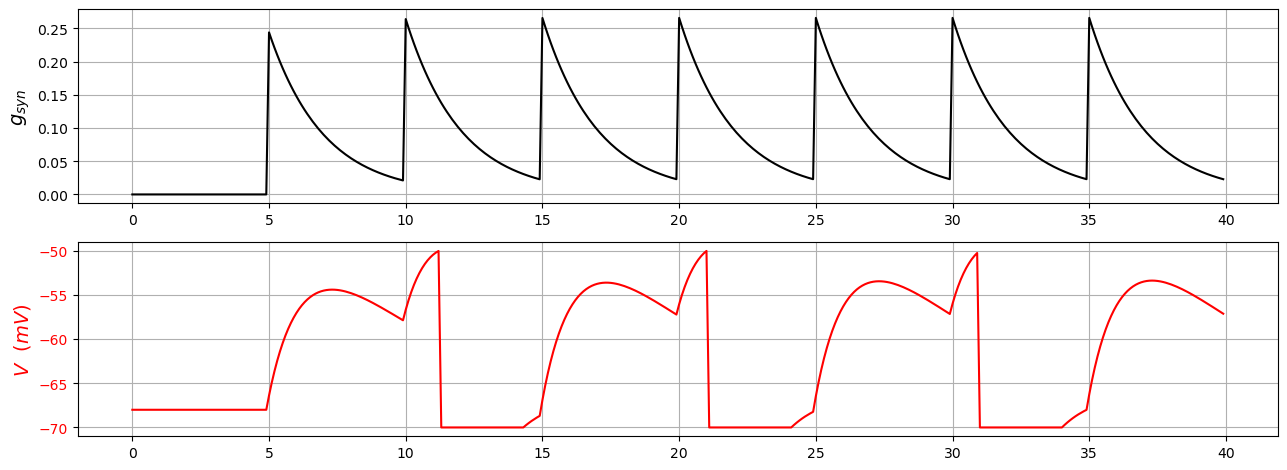

In [39]:
# watch one LIF cell for Tfin ms and dt ms timestep and presynaptic spikes every P ms

import numpy as np
import matplotlib.pyplot as plt
import math

fig, (ax1, ax2) = plt.subplots(2, 1)
plt.subplots_adjust(right=2, top=1, wspace=0.25)
    
Tfin = 40    # ms
dt = 0.1     # ms
P = 5       # ms

Nt = math.ceil(Tfin/dt)
tausyn = 2 
Vsyn = 0

gL = 0.3 
VL = -68 
Cm = 1

wsyn = 0.5 

aE = (2*tausyn-dt)/(2*tausyn+dt)  
bE = 2/(2*tausyn+dt)

tref = 3
Vthr = -50
Vres = -70

gsyn = np.zeros(Nt) 
V = VL*np.ones(Nt) 

T = -10    # time of last spike

t = np.zeros(Nt) 

for j in range(1,Nt):   

    t[j] = j*dt
    spin = (t[j]/P == round(t[j]/P))
    gsyn[j] = aE*gsyn[j-1] + bE*wsyn*spin

    if (t[j]-T) > tref:
        n1 = (2*Cm/dt-(gL+gsyn[j]))*V[j-1] + 2*gL*VL + 2*gsyn[j]*Vsyn
        d1 = 2*Cm/dt + gL + gsyn[j]
        tmp = n1/d1
        if tmp < Vthr:
            V[j] = tmp
        else:
            V[j] = Vres
            T = t[j]       # spike time
    else:
        V[j] = Vres

ax1.plot(t,gsyn,'k')
ax1.grid('on')
ax1.set_ylabel('$g_{syn}$', color='k',fontsize=14)
ax1.tick_params(axis="y", labelcolor='k')

ax2.plot(t,V,'r')
ax2.grid('on')
ax2.set_ylabel('$V$  $(mV)$', color='r',fontsize=14)
ax2.tick_params(axis="y", labelcolor='r');


\begin{myfig}\label{fig:1cell} The synaptic conductance and membrane voltage of an integrate and fire neuron receiving a presynaptic spike every 5 ms. Do you see it spike every 10 ms and stay refractory for 3 ms? Please explore several other values of the presynaptic spike period, $P$.  \end{myfig}

# Integrate and Fire Networks

We move on to small then large with both excitatory and inhibitory conductances. We begin with the simple two cell network below. A neuron is deemed **excitatory** when it "depolarizes" (i.e., raises the voltage) of its post-synaptic targets, and is deemed **inhibitory** when it "hyperpolarizes" (i.e., lowers the voltage) of its post-synaptic targets. At the level of our modeling, excitatory synapses have depolarizing synaptic potentials, e.g., $V_{syn}>V_{thr}$, while inhibitory synapses have hyperpolarizing synaptic potentials, e.g., $V_{syn}\approx V_L$.  

We will begin by with a network of two cells, driven by excitatory synapses.

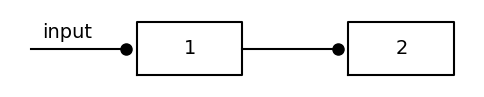

In [33]:
# draw a 2 cell network

import matplotlib.pyplot as plt

plt.figure(figsize=(6, 1))   

plt.plot([0,0.9],[0,0],'k')
plt.text(.1,.1,'input', fontsize=14)
plt.plot(0.9,0,'ko',markersize=8)
plt.plot([1,1,2,2,1],[-0.25, 0.25, 0.25, -0.25, -0.25],'k')
plt.text(1.45,-.05,'1',fontsize=14)

plt.plot([2,2.9],[0,0],'k')
plt.plot(2.9,0,'ko',markersize=8)
plt.plot([3,3,4,4,3],[-0.25, 0.25, 0.25, -0.25, -0.25],'k')
plt.text(3.45,-.05,'2',fontsize=14)

plt.axis('equal')
plt.axis('off');

\begin{myfig}\label{fig:2cell} The smallest network, consisting of two cells driven by two excitatory conductances.\end{myfig}

We denote the membrane potentials by $V_1$ and $V_2$,
and conductances  by $g_{E,1}$ and $g_{E,2}$. The circuit is
driven by an excitatory input train that spikes at $T_{inp}\equiv\{T_{inp}^n:n=1,2,\ldots\}$. 
Each such spike increments $g_{E,1}$, the excitatory conductance at
cell 1, by a fixed amount, $w^{inp}/\tau_E$. Between such spikes we assume that
$g_{E,1}$ returns to zero at the fixed rate $\tau_E$. In other words,
we suppose that $g_{E,1}$ is governed by the differential equation

\begin{equation}\label{eq:ge1}
  \tau_E g'_{E,1}(t) = -g_{E,1}(t) + w^{inp}\sum_n\delta(t-T^n_{inp}).
\end{equation}

Similarly, the excitatory conductance at cell 2 is driven by the
spikes of cell 1, at times $T_1\equiv\{T_1^n:n=1,2,\ldots\}$ and with weight $w_{21}$. 
It follows that $g_{E,2}$ is governed by

\begin{equation}\label{eq:ge2}
  \tau_E g'_{E,2}(t) = -g_{E,2}(t) + w_{21}\sum_n\delta(t-T_1^n). 
\end{equation}

These conductances in turn supply synaptic current to the potential equations

\begin{equation}\label{eq:Viaf}
   C_mV'_i(t) = g_L(V_L-V_i(t))+g_{E,i}(t)(V^{syn}_E-V_i(t)),
      \hskip 0.25in\hbox{while}\hskip 0.25in V_i(t)<V_{thr}  
\end{equation}

and cell $i$ is not refractory. When $V_i(t)$ exceeds $V_{thr}$ we augment the
spike time sequence, $T_i$, and we reset $V_i(t)$ to a fixed reset potential,
$V_{res}$, for a set refractory period, $t_{ref}$.
These spike times couple the conductance and potential equations. 
We decouple this system by choosing a time step, $dt$, and specifying an order of
operation. In particular, we adopt the same marching scheme as that used for the single cell

[1] check for an input spike at the **current** time, $t$, and
for network spikes from the **previous** time, $t-dt$,

[2] update conductances based on the input spikes and network spikes
recorded in [1]

[3] update potentials, record spikes and return to [1]

Our coding of this below, for a "standard" set of parameters is just a doubling of the code we wrote for the single cell.

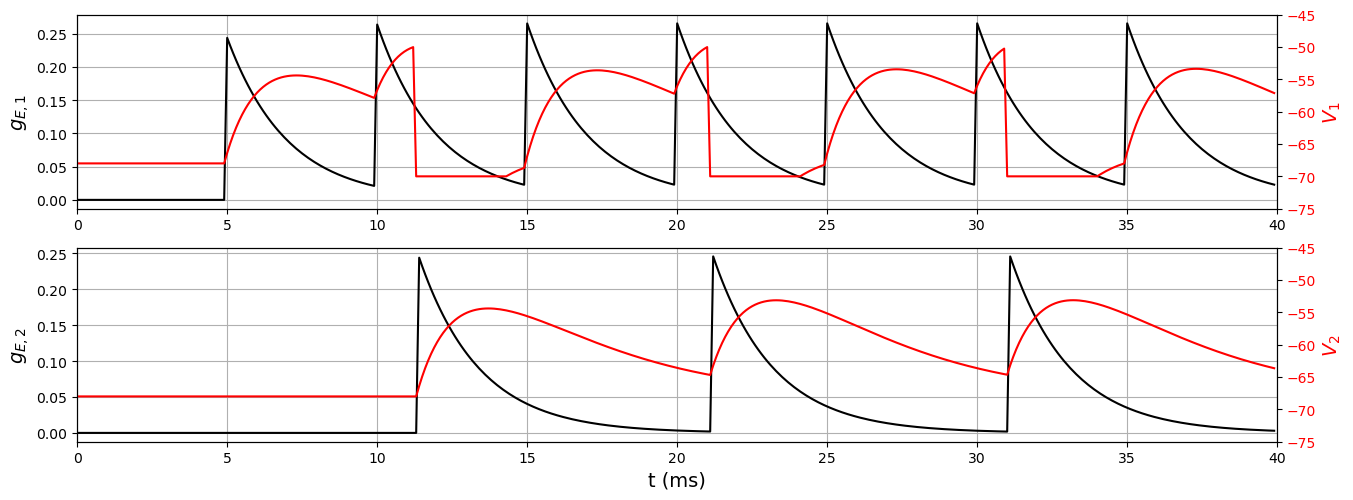

In [40]:
# from twocell.m   

import numpy as np
import matplotlib.pyplot as plt
import math

fig, (ax1, ax3) = plt.subplots(2, 1)
plt.subplots_adjust(right=2, top=1, wspace=0.25)
ax2 = ax1.twinx()
ax4 = ax3.twinx()
    
Tfin = 40
dt = 0.1
P = 5

Nt = math.ceil(Tfin/dt)
tauE = 2 
VE = 0

gL = 0.3 
VL = -68 
Cm = 1

winp = 0.5 
w21 = 0.5

aE = (2*tauE-dt)/(2*tauE+dt)  
bE = 2/(2*tauE+dt)

tref = 3
Vthr = -50
Vres = -70

gE1 = np.zeros(Nt) 
gE2 = np.zeros(Nt)
V1 = VL*np.ones(Nt) 
V2 = VL*np.ones(Nt)

sp1 = 0 
sp2 = 0 
T1 = -10 
T2 = -10

t = np.zeros(Nt) 

for j in range(1,Nt):   

    t[j] = j*dt
    spin = (t[j]/P == round(t[j]/P))
    gE1[j] = aE*gE1[j-1] + bE*winp*spin
    gE2[j] = aE*gE2[j-1] + bE*w21*sp1

    if (t[j]-T1) > tref:
        n1 = (2*Cm/dt-(gL+gE1[j]))*V1[j-1] + 2*gL*VL
        d1 = 2*Cm/dt + gL + gE1[j]
        tmp = n1/d1
        if tmp < Vthr:
            V1[j] = tmp
        else:
            V1[j] = Vres
            sp1 = 1
            T1 = t[j]
    else:
        sp1 = 0
        V1[j] = Vres

    if (t[j]-T2) > tref:
        n2 = (2*Cm/dt-(gL+gE2[j]))*V2[j-1] + 2*gL*VL
        d2 = 2*Cm/dt + gL + gE2[j]
        tmp = n2/d2
        if tmp < Vthr:
            V2[j] = tmp
        else:
            V2[j] = Vres
            sp2 = 1
            T2 = t[j]
    else:          
        sp2 = 0
        V2[j] = Vres

ax1.plot(t,gE1,'k')
ax1.grid('on')
ax1.set_ylabel('$g_{E,1}$', color='k',fontsize=14)
ax1.tick_params(axis="y", labelcolor='k')

ax2.plot(t,V1,'r')
ax2.set_ylabel('$V_1$', color='r',fontsize=14)
ax2.tick_params(axis="y", labelcolor='r')
ax2.axis([0,40,-75,-45])

ax3.plot(t,gE2,'k')
ax3.grid('on')
ax3.set_xlabel('t (ms)',fontsize=14)
ax3.set_ylabel('$g_{E,2}$', color='k',fontsize=14)
ax3.tick_params(axis="y", labelcolor='k')

ax4.plot(t,V2,'r')
ax4.set_ylabel('$V_2$', color='r',fontsize=14)
ax4.tick_params(axis="y", labelcolor='r')
ax4.axis([0,40,-75,-45]);

\begin{myfig}\label{fig:twocell}. Response of the two cell net to low frequency, $P=5$, stimulus. Voltage is in mV and conductance mS/cm$^2$. The stimuli and cells are parametrized in (\ref{eq:Pstim}) and (\ref{eq:netpar}). We see that cell one fires following every second input spike. In this case the resultant spike rate of cell 1 is not sufficient to bring cell 2 to threshold. Please vary the $P$ and perhaps other parameters, to get cell 2 to spike.
\end{myfig}

As our goal is to simulate networks with thousands of cells, with each cell receiving input from many others, we need a better way to manage our data and visualize our spikes.

To get started, lets examine the network below of 3 excitatory cells, one of which has two synapses.

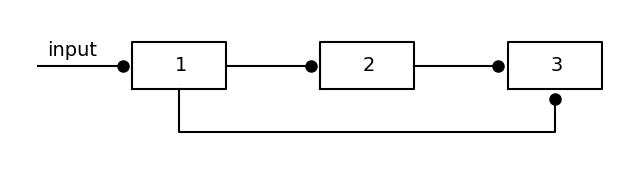

In [32]:
# draw a 3 cell network

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 2))   

plt.plot([0,0.9],[0,0],'k')
plt.plot(0.9,0,'ko',markersize=8)
plt.text(.1,.1,'input', fontsize=14)
plt.plot([1,1,2,2,1],[-0.25, 0.25, 0.25, -0.25, -0.25],'k')
plt.text(1.45,-.05,'1',fontsize=14)

plt.plot([2,2.9],[0,0],'k')
plt.plot(2.9,0,'ko',markersize=8)
plt.plot([3,3,4,4,3],[-0.25, 0.25, 0.25, -0.25, -0.25],'k')
plt.text(3.45,-.05,'2',fontsize=14)

plt.plot([4,4.9],[0,0],'k')
plt.plot(4.9,0,'ko',markersize=8)
plt.plot([5,5,6,6,5],[-0.25, 0.25, 0.25, -0.25, -0.25],'k')
plt.text(5.45,-.05,'3',fontsize=14)

plt.plot([1.5,1.5,5.5,5.5],[-.25,-.7,-.7,-.35],'k')
plt.plot(5.5,-.35,'ko',markersize=8)

plt.axis('equal')
plt.axis('off');

\begin{myfig}\label{fig:3cell} A three cell network with four excitatory connections.\end{myfig}

We have coded the subsequent model below. This code is a considerable
refinement of the two cell version. In particular, we have *vectorized* the computations of both $g_E$ and $V$ and have laid the weights in a weight matrix $W$. We then update all the synaptic conductances at once in the single line

```
gE[:,j] = aE*gE[:,j-1] + bE*(W@sp + spin*Win)
```
where sp[i] is 1 or 0 as cell i has just spiked or not. Similarly, spin is 1 or 0 depending on the timing of input spikes. The weight matrices and vectors are

\begin{equation}\label{eq:W3}
  W = \begin{bmatrix} 0 & 0 & 0 \\ 0.5 & 0 & 0 \\ 0.5 & 0.5 & 0 \end{bmatrix}
  \hskip 0.25in \hbox{and} \hskip 0.25in 
  Win = \begin{bmatrix} 0.5 \\ 0 \\ 0  \end{bmatrix}
\end{equation}

Here $W[r,c]\ne 0$ when cell number $c$ is presynaptic to cell $r$, where $r$ and $c$ denote row and column indicies of $W$. The python symbol for matrix vector multiplication is $@$. You can see below that this is a fantastic streamlining of our code.

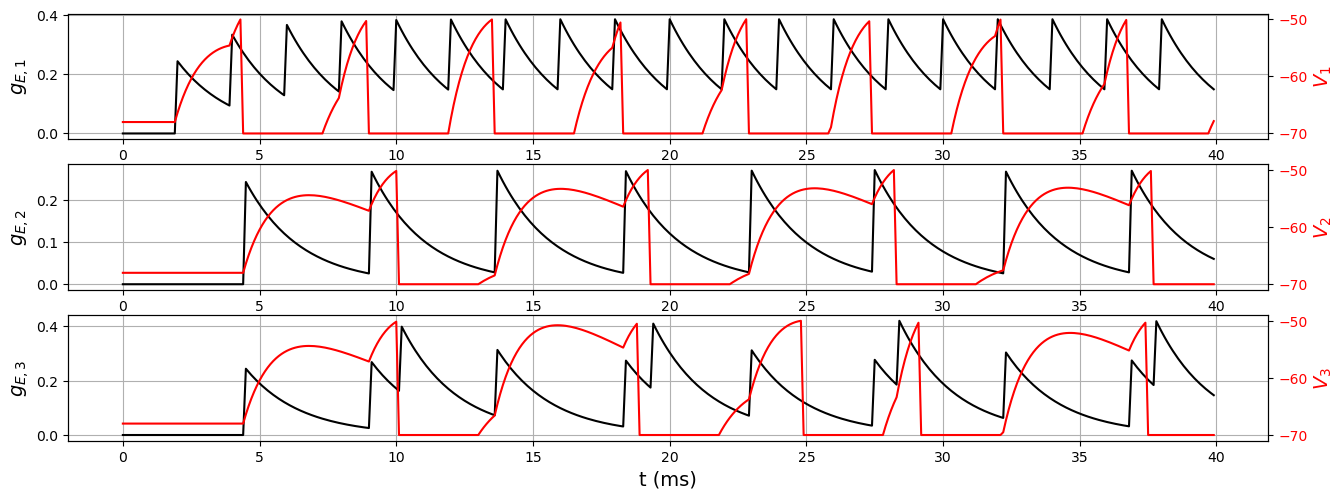

In [46]:
# threecell   threecell(dt,Tfin,P)

import numpy as np
import matplotlib.pyplot as plt
import math

fig, (ax1, ax3, ax5) = plt.subplots(3, 1)
plt.subplots_adjust(right=2, top=1, wspace=0.25)
ax2 = ax1.twinx()
ax4 = ax3.twinx()
ax6 = ax5.twinx()
    
Tfin = 40
dt = 0.1
P = 2
Nt = math.ceil(Tfin/dt)
tauE = 2 
VE = 0
gL = 0.3 
VL = -68 
Cm = 1
Win = np.array([0.5, 0, 0])
w = 0.5   # 0.26
W = np.array([[0, 0, 0], [0.5, 0, 0], [w, w, 0]])
aE = (2*tauE-dt)/(2*tauE+dt)  
bE = 2/(2*tauE+dt)
tref = 3
Vthr = -50
Vres = -70
gE = np.zeros((3,Nt))
V = VL*np.ones((3,Nt))
t = np.zeros(Nt)
sp = np.zeros(3) 
T = -10*np.ones(3) 
ref = np.zeros(3)

for j in range(1,Nt):

    t[j] = j*dt

    spin = (t[j]/P==round(t[j]/P))

    gE[:,j] = aE*gE[:,j-1] + bE*(W@sp + spin*Win)

    top = (2*Cm/dt - (gL+gE[:,j]))*V[:,j-1] + 2*gL*VL  # elementwise
    bot = 2*Cm/dt + gL + gE[:,j]
    V[:,j] = top/bot

    ref = np.where( t[j]-T < tref )
    V[ref,j] = Vres

    sp = (V[:,j] > Vthr)

    if sum(sp)>0:
        fsp = np.where(sp>0)
        T[fsp] = t[j]
        V[fsp,j] = Vres

ax1.plot(t,gE[0,:],'k')
ax1.grid('on')
ax1.set_ylabel('$g_{E,1}$', color='k',fontsize=14)
ax1.tick_params(axis="y", labelcolor='k')

ax2.plot(t,V[0,:],'r')
ax2.set_ylabel('$V_1$', color='r',fontsize=14)
ax2.tick_params(axis="y", labelcolor='r')

ax3.plot(t,gE[1,:],'k')
ax3.grid('on')
ax3.set_ylabel('$g_{E,2}$', color='k',fontsize=14)
ax3.tick_params(axis="y", labelcolor='k')

ax4.plot(t,V[1,:],'r')
ax4.set_ylabel('$V_2$', color='r',fontsize=14)
ax4.tick_params(axis="y", labelcolor='r')

ax5.plot(t,gE[2,:],'k')
ax5.grid('on')
ax5.set_xlabel('t (ms)',fontsize=14)
ax5.set_ylabel('$g_{E,3}$', color='k',fontsize=14)
ax5.tick_params(axis="y", labelcolor='k')

ax6.plot(t,V[2,:],'r')
ax6.set_ylabel('$V_3$', color='r',fontsize=14)
ax6.tick_params(axis="y", labelcolor='r')

\begin{myfig}\label{fig:threecell} Response of the three cell excitatory net to a high frequency, $P=2$,
stimulus. Observe in the lower panel that the third conductance receives a double kick as cell 2 fires just
after each second spike of cell 1. \end{myfig}

We next suppose, see Figure \ref{fig:3cellI}, that cell 3 inhibits cell 1. This new conductance is governed by 

\begin{equation*}
  g_{I,1}^j = a_Ig_{I,1}^{j-1} + b_Iw_{inh}s_3^j
\end{equation*}

where $s_3^j$ is one if  cell $3$ spiked at time $j$, and is zero otherwise. In addition, as in the excitatory case,

\begin{equation*}
a_I = \frac{2\tau_I-dt}{2\tau_I+dt} \hskip 0.25in \hbox{and} \hskip 0.25in b_I = \frac{2}{2\tau_I+dt}.
\end{equation*}

and potential at cell 1 now follows

\begin{equation*}
 V_1^j = \frac{(2C_m/dt-(g_L+g_{E,1}^j+g_{I,1}^j))V_1^{j-1} + 2g_LV_L + 
             (g_{E,1}^j+g_{E,1}^j)V^{syn}_E + (g_{I,1}^{j+1}+g_{I,1}^j)V^{syn}_I}
                   {2C_m/dt+g_L+g_{E,1}^{j+1} + g_{I,1}^{j+1} }.
\end{equation*}

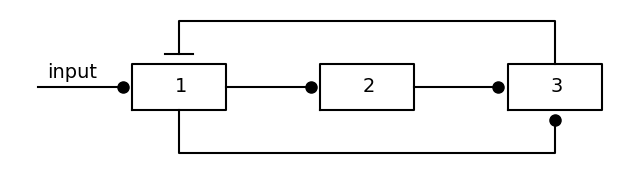

In [43]:
# draw a 3 cell network with inhibition

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 2))   

plt.plot([0,0.9],[0,0],'k')
plt.plot(0.9,0,'ko',markersize=8)
plt.text(.1,.1,'input', fontsize=14)
plt.plot([1,1,2,2,1],[-0.25, 0.25, 0.25, -0.25, -0.25],'k')
plt.text(1.45,-.05,'1',fontsize=14)

plt.plot([2,2.9],[0,0],'k')
plt.plot(2.9,0,'ko',markersize=8)
plt.plot([3,3,4,4,3],[-0.25, 0.25, 0.25, -0.25, -0.25],'k')
plt.text(3.45,-.05,'2',fontsize=14)

plt.plot([4,4.9],[0,0],'k')
plt.plot(4.9,0,'ko',markersize=8)
plt.plot([5,5,6,6,5],[-0.25, 0.25, 0.25, -0.25, -0.25],'k')
plt.text(5.45,-.05,'3',fontsize=14)

plt.plot([1.5,1.5,5.5,5.5],[-.25,-.7,-.7,-.35],'k')
plt.plot(5.5,-.35,'ko',markersize=8)

plt.plot([1.5,1.5,5.5,5.5],[.35,.7,.7,.25],'k')
plt.plot([1.35,1.65],[.35,.35],'k')

plt.axis('equal')
plt.axis('off');

\begin{myfig}\label{fig:3cellI} A three-cell network with feedback inhibition.\end{myfig} 

We set 

\begin{equation*}
  \tau_I = 2\ \text{ms}, \ V^{syn}_I = -70\ \text{mV} \hskip 0.25in \hbox{and} \hskip 0.25in w_{inh} =
3\ \text{mSms}/\text{cm}^2,
\end{equation*}

and arrive at the trajectories of Figure \ref{fig:threecellI}.

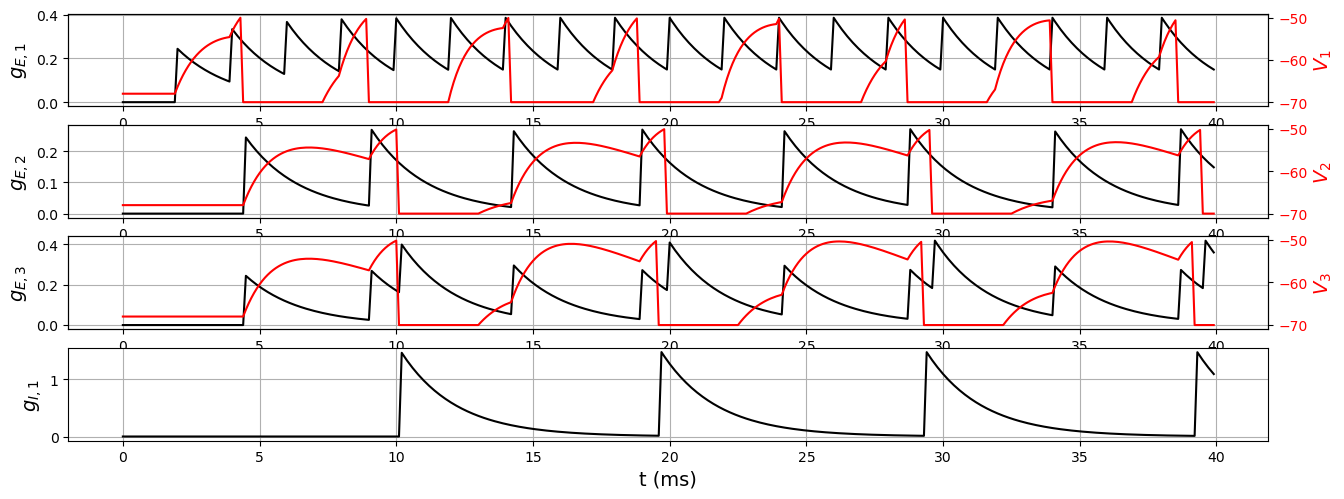

In [49]:
# threecellI   

import numpy as np
import matplotlib.pyplot as plt
import math

fig, (ax1, ax3, ax5, ax7) = plt.subplots(4, 1)
plt.subplots_adjust(right=2, top=1, wspace=0.25)
ax2 = ax1.twinx()
ax4 = ax3.twinx()
ax6 = ax5.twinx()
    
Tfin = 40
dt = 0.1
P = 2
Nt = math.ceil(Tfin/dt)
tauE = 2 
VE = 0
gL = 0.3 
VL = -68 
Cm = 1
Win = np.array([0.5, 0, 0])
w = 0.5   # 0.26
W = np.array([[0, 0, 0], [0.5, 0, 0], [w, w, 0]])
aE = (2*tauE-dt)/(2*tauE+dt)  
bE = 2/(2*tauE+dt)
tref = 3
Vthr = -50
Vres = -70
gE = np.zeros((3,Nt))
V = VL*np.ones((3,Nt))
t = np.zeros(Nt)
sp = np.zeros(3) 
T = -10*np.ones(3) 
ref = np.zeros(3)

tauI = 2
VsynI = -70
Winh = 3
gI = np.zeros(Nt)
aI = (2*tauI-dt)/(2*tauI+dt)
bI = 2/(2*tauI+dt);

for j in range(1,Nt):

    t[j] = j*dt

    spin = (t[j]/P==round(t[j]/P))

    gE[:,j] = aE*gE[:,j-1] + bE*(W@sp + spin*Win)
    gI[j] = aI*gI[j-1] + bI*Winh*sp[2];

    top = (2*Cm/dt - (gL+gE[:,j]))*V[:,j-1] + 2*gL*VL  # elementwise
    top[0] = top[0] - gI[j]*V[0,j] + (gI[j]+gI[j])*VsynI

    bot = 2*Cm/dt + gL + gE[:,j]
    bot[0] = bot[0] + gI[j]
                                 
    V[:,j] = top/bot

    ref = np.where( t[j]-T < tref )
    V[ref,j] = Vres

    sp = (V[:,j] > Vthr)

    if sum(sp)>0:
        fsp = np.where(sp>0)
        T[fsp] = t[j]
        V[fsp,j] = Vres

ax1.plot(t,gE[0,:],'k')
ax1.grid('on')
ax1.set_ylabel('$g_{E,1}$', color='k',fontsize=14)
ax1.tick_params(axis="y", labelcolor='k')

ax2.plot(t,V[0,:],'r')
ax2.set_ylabel('$V_1$', color='r',fontsize=14)
ax2.tick_params(axis="y", labelcolor='r')

ax3.plot(t,gE[1,:],'k')
ax3.grid('on')
ax3.set_ylabel('$g_{E,2}$', color='k',fontsize=14)
ax3.tick_params(axis="y", labelcolor='k')

ax4.plot(t,V[1,:],'r')
ax4.set_ylabel('$V_2$', color='r',fontsize=14)
ax4.tick_params(axis="y", labelcolor='r')

ax5.plot(t,gE[2,:],'k')
ax5.grid('on')
ax5.set_ylabel('$g_{E,3}$', color='k',fontsize=14)
ax5.tick_params(axis="y", labelcolor='k')

ax6.plot(t,V[2,:],'r')
ax6.set_ylabel('$V_3$', color='r',fontsize=14)
ax6.tick_params(axis="y", labelcolor='r')
                                      
ax7.plot(t,gI,'k')
ax7.grid('on')
ax7.set_xlabel('t (ms)',fontsize=14)
ax7.set_ylabel('$g_{I,1}$', color='k',fontsize=14);

\begin{myfig}\label{fig:threecellI} Response of the network in Figure \ref{fig:3cellI} to a high frequency, $P=2$, stimulus. We note that cell 3 now staggers the firing of cell 1. \end{myfig}

In the simulation of large networks, one computes, but does not typically report, the conductances and potentials at each time step. Rather one reports the times at which each cell
spikes. We have trimmed the previous code blocks to just show these spikes.

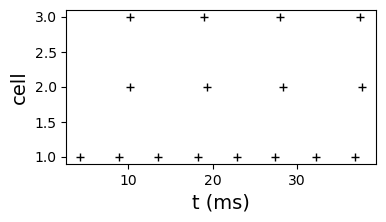

In [48]:
# threecellrast

import numpy as np
import matplotlib.pyplot as plt
import math

fig, ax = plt.subplots(figsize=(4, 2))
    
Tfin = 40
dt = 0.1
P = 2
Nt = math.ceil(Tfin/dt)
tauE = 2 
VE = 0
gL = 0.3 
VL = -68 
Cm = 1
Win = np.array([0.5, 0, 0])
w = 0.5   # 0.26
W = np.array([[0, 0, 0], [0.5, 0, 0], [w, w, 0]])
aE = (2*tauE-dt)/(2*tauE+dt)  
bE = 2/(2*tauE+dt)
tref = 3
Vthr = -50
Vres = -70
gE = np.zeros(3)
V = VL*np.ones(3)
sp = np.zeros(3) 
T = -10*np.ones(3) 
ref = np.zeros(3)

a = 2*Cm/dt
b = 2*gL*VL
c = a + gL;

for j in range(1,Nt):

    t = j*dt

    spin = (t/P==round(t/P))

    gEo = gE   # previous gE
    gE = aE*gE + bE*(W@sp + spin*Win)

    V = ( (a - (gL + gEo))*V + b ) /  (c + gE)

    ref = np.where( t-T < tref )
    V[ref] = Vres

    sp = (V > Vthr)

    if sum(sp)>0:
        fsp = np.where(sp>0)[0]
        T[fsp] = t
        V[fsp] = Vres
        for ind in fsp:
            ax.plot(t,1+ind,'k+')

ax.set_xlabel('t (ms)',fontsize=14)
ax.set_ylabel('cell', color='k', fontsize=14);

\begin{myfig}\label{fig:threecellrast} Raster plot of spike times of the excitatory three cell net subject to  high frequency, $P=2$, stimulus.\end{myfig}

Proceeding to larger networks with $N$ excitatory cells, we suppose that
$W$ denotes the $N$-by-$N$ matrix of synaptic weights and
$W_{inp}$ denotes the $N$-by-1 weight of input spikes, then, arguing as above, the
network equations take the form

\begin{equation}\label{eq:LLIF}
\eqalign{
  g_E^j &= a_Eg_E^{j-1} + b_E(Ws^{j-1} + W_{inp}s^j_{inp}) \cr
    V^j &= \frac{(2C_m/dt-(g_L+g_E^j))V^{j-1} + 2g_LV_L + 
                          (g_E^{j-1}+g_E^j)V^{syn}_E}{2C_m/dt+g_L+g_E^j} \cr
  s^j &= V^j > V_{thr} \cr}
\end{equation}

where all operations in the voltage update are element-wise. Here $s^j$ and $s^j_{inp}$ are vectors with binary, i.e.,
$\{0,1\}$, elements. We set  $s^j_{inp,i}=1$ if cell $i$ receives an input spike at time $jdt$. Similarly, we set
$s^j_i=1$ if cell $i$ spiked (exceeded threshold) at time $jdt$.

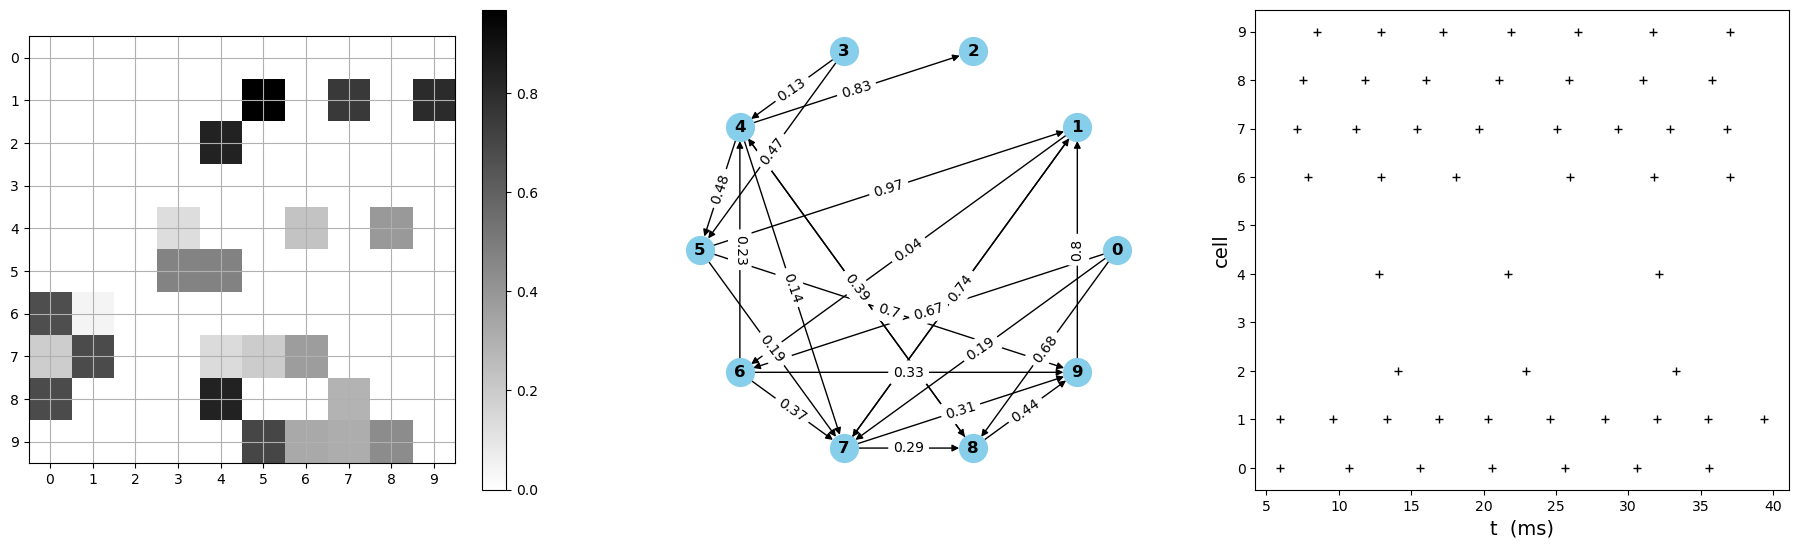

In [144]:
# build and view (two ways) a random weight matrix and record its raster of spikes

import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import random_array 
import networkx as nx

fig, (ax1, ax2, ax3) = plt.subplots(1,3)
plt.subplots_adjust(right=3, left=0.25, wspace=0.15, top=1, bottom=0)  

# Define shape (rows, cols) and density (fraction of non-zero elements)
rows, cols = 10, 10
density = 0.25  # 25% of the elements will be non-zero
rng = np.random.default_rng(42)  # make it reproducible

# Generate the sparse array
sparse_matrix = random_array((rows, cols), density=density, format='csr', random_state=rng) 
W = sparse_matrix.toarray()
for r in range(rows):
    W[r,r] = 0.0                # remove autapses

im1 = ax1.imshow(W, cmap='gray_r')
fig.colorbar(im1, ax=ax1)
ax1.set_xticks(np.linspace(0,9,10))
ax1.set_yticks(np.linspace(0,9,10))
ax1.grid('on')

# now view it as a directed weighted graph

Wt2 = np.round(W.T,2)   # transpose and round
G = nx.from_numpy_array(Wt2, create_using=nx.DiGraph)

pos = nx.circular_layout(G)  # Layout algorithm for positioning nodes
nx.draw(
    G,
    pos,
    ax=ax2,
    with_labels=True,
    node_color="skyblue",
    node_size=400,
    font_weight="bold",
)
labels = nx.get_edge_attributes(G, "weight")
nx.draw_networkx_edge_labels(G, pos, ax = ax2, edge_labels=labels)
ax2.set_aspect('equal')

# now use it in a network

Nt = math.ceil(Tfin/dt)
P = 5
tauE = 2 
gL = 0.3
VL = -68
Cm = 1
N = rows
Win = np.zeros(N)
Win[0:2] = 1

aE = (2*tauE-dt)/(2*tauE+dt)
bE = 2/(2*tauE+dt)

tref = 3
Vthr = -50
Vres = -70

gE = np.zeros(N)
V = VL*np.ones(N)

sp = np.zeros(N)
T = -10*np.ones(N)
ref = np.zeros(N);

a = 2*Cm/dt
b = 2*gL*VL
c = a + gL

for j in range(1,Nt-1):

    t = j*dt

    spin = (t/P==round(t/P))

    gEo = gE

    gE = aE*gE + bE*(W@sp + spin*Win)

    V = ( (a - (gL + gEo))*V + b ) /  (c + gE)

    ref = np.where( t-T < tref )
    V[ref] = Vres

    sp = (V>Vthr)

    if sum(sp)>0:
        fsp = np.where(sp>0)[0];
        T[fsp] = t;
        V[fsp] = Vres;
        for ind in fsp:
            ax3.plot(t,ind,'k+')

ax3.set_yticks(np.linspace(0,9,10))
ax3.set_xlabel('t  (ms)', fontsize=14)
ax3.set_ylabel('cell', fontsize=14);

\begin{myfig}\label{fig:Enet20} Weight matrix (left), weighted directed graph (center) and spikes (right) in a 10-cell
excitatory net with $25\%$ connectivity subject to a periodic train, $P=5$, with $W_{inp}=1$,
delivered to the first 2 cells. We note that rows 0 and 3 of $W$ have no weights and so no inputs from any other cell. Similarly, column 2 of $W$ has no weights and so does not influence any other cell. 
Cell 0 spikes with each input while Cell 1 spikes faster. Why is that? Can you explain the rest of the spikes?\end{myfig}


We now introduce a population of inhibitory cells. We denote their potentials by $V_I$ and
those of the excitatory cells by $V_E$. Now each cell has two conductances; $g_{EE}$ and
$g_{IE}$ will denote the excitatory and inhibitory conductances on an excitatory cell 
while $g_{EI}$ and $g_{II}$ will denote the excitatory and inhibitory conductances on an 
inhibitory cell. 
Coupling occurs through the weight matrices;

$W_{EE}$ which connects E cells to E cells, 

$W_{EI}$ which connects E cells to I cells,

$W_{IE}$, which connects I cells to E cells, 

and $W_{II}$ which connects I cells to I cells.

The subsequent network equations are

\begin{equation*}
  \eqalign{
  g_{EE}^j &= a_Eg_{EE}^{j-1} + b_E(W_{EE}s_E^{j-1} + W^{inp}_{EE}s^j_{inp,E}) \\ 
  g_{EI}^j &= a_Eg_{EI}^{j-1} + b_E(W_{EI}s_E^{j-1} +
W^{inp}_{EI}s^j_{inp,E}) \\  
  g_{II}^j &= a_Ig_{II}^{j-1} + b_I(W_{II}s_I^{j-1} +
W^{inp}_{II}s^j_{inp,I}) \\  
  g_{IE}^j &= a_Ig_{IE}^{j-1} + b_I(W_{IE}s_I^{j-1} +
W^{inp}_{IE}s^j_{inp,I}) \\  
  V_E^j &= \frac{(2C_m/dt-(g_L+g_{EE}^{j-1}+g_{IE}^{j-1}))V_E^{j-1} + 2g_LV_L + 
             (g_{EE}^j+g_{EE}^{j-1})V^{syn}_E + (g_{IE}^j+g_{IE}^{j-1})V^{syn}_I}
                   {2C_m/dt+g_L+g_{EE}^j + g_{IE}^j } \\
  V_I^j &= \frac{(2C_m/dt-(g_L+g_{II}^{j-1}+g_{EI}^{j-1}))V_I^{j-1} + 2g_LV_L + 
             (g_{II}^j+g_{II}^{j-1})V^{syn}_I + (g_{EI}^j+g_{EI}^{j-1})V^{syn}_E}
                   {2C_m/dt+g_L+g_{II}^j + g_{EI}^j } \\
  s_E^j &= V_E^j > V_{thr} \\
  s_I^j &= V_I^j > V_{thr}.}
\end{equation*}

We have coded this system below with 
$$
  \tau_I = 1\ \text{ms} \hskip 0.25in \hbox{and} \hskip 0.25in V^{syn}_I = -70\ \text{mV}
$$

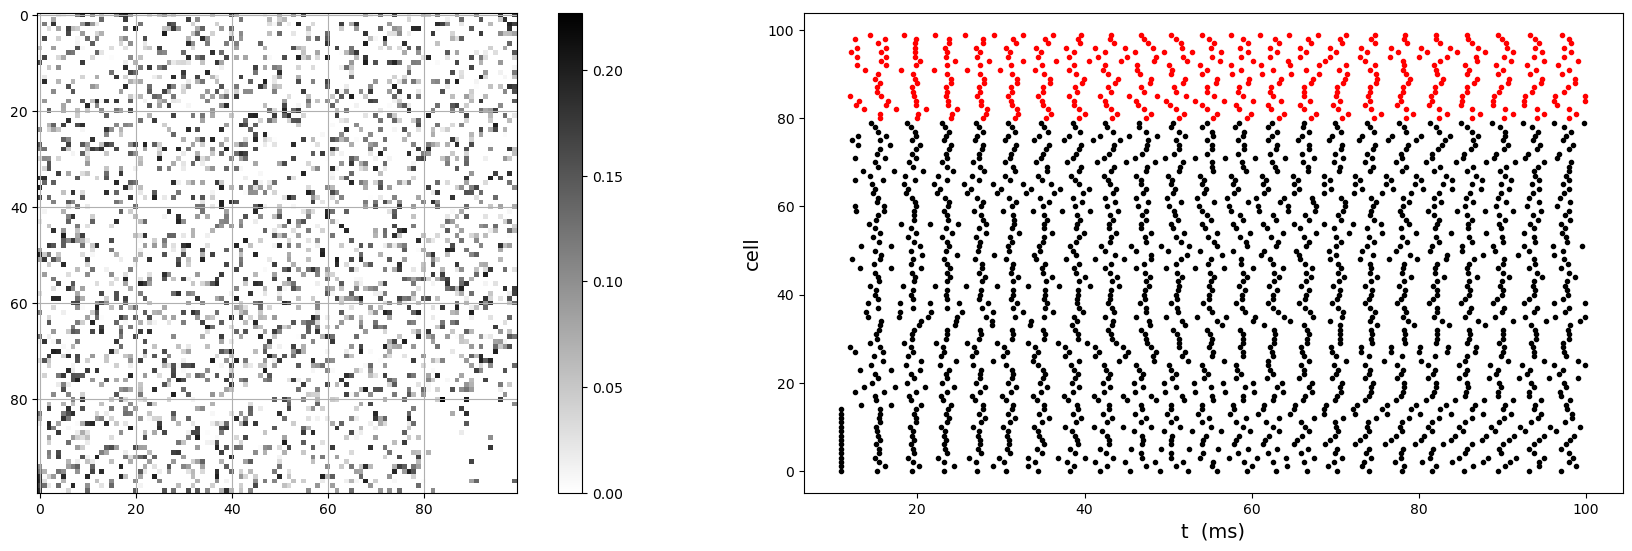

In [7]:
# EInet

import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import random_array 
import networkx as nx

fig, (ax1, ax2) = plt.subplots(1,2)
plt.subplots_adjust(right=3, left=0.25, wspace=0.15, top=1, bottom=0) 

EInet = {"NE":80, "NI":20, "denEE":0.25, "denEI":0.25, "denIE":0.25, "denII":0.05}

rng = np.random.default_rng(42)  # make it reproducible

sparse_matrix = random_array((EInet["NE"], EInet["NE"]), density=EInet["denEE"], format='csr', random_state=rng) 
WEE = sparse_matrix.toarray()/5
for r in range(EInet["NE"]):
    WEE[r,r] = 0.0                # remove autapses
    
sparse_matrix = random_array((EInet["NI"], EInet["NE"]), density=EInet["denEI"], format='csr', random_state=rng) 
WEI = sparse_matrix.toarray()/5

sparse_matrix = random_array((EInet["NE"], EInet["NI"]), density=EInet["denIE"], format='csr', random_state=rng) 
WIE = sparse_matrix.toarray()/5

sparse_matrix = random_array((EInet["NI"], EInet["NI"]), density=EInet["denII"], format='csr', random_state=rng) 
WII = sparse_matrix.toarray()/4
for r in range(EInet["NI"]):
    WII[r,r] = 0.0                # remove autapses
    
W = np.block([[WEE, WIE],[WEI, WII]])    # assemble for visualization
im1 = ax1.imshow(W, cmap='gray_r')
fig.colorbar(im1, ax=ax1)
ax1.grid('on')

Tfin = 100
dt = 0.1
P = 10

Nt = math.ceil(Tfin/dt)

tauE = 2 
VsynE = 0
tauI = 1 
VsynI = -70

gL = 0.3 
VL = -68 
Cm = 1

WinEE = np.zeros(EInet["NE"])                        
WinEE[0:15] = 1        # drive 1st 16 E cells

aE = (2*tauE-dt)/(2*tauE+dt) 
bE = 2/(2*tauE+dt)

aI = (2*tauI-dt)/(2*tauI+dt) 
bI = 2/(2*tauI+dt)

tref = 3 
Vthr = -50 
Vres = -70

gEE = np.zeros(EInet["NE"]) 
VE = VL*np.ones(EInet["NE"]) 

gII = np.zeros(EInet["NI"]) 
VI = VL*np.ones(EInet["NI"]) 

gEI = np.zeros(EInet["NI"]) 

gIE = np.zeros(EInet["NE"]) 

spE = np.zeros(EInet["NE"]) 
TE = -10*np.ones(EInet["NE"]) 

spI = np.zeros(EInet["NI"])
TI = -10*np.ones(EInet["NI"]) 

a = 2*Cm/dt 
b = 2*gL*VL 
c = a + gL

for j in range(1,Nt):

    t = j*dt

    spin = (t/P==round(t/P))

    gEEo = gEE
    gEE = aE*gEE + bE*(WEE@spE + spin*WinEE)

    gEIo = gEI
    gEI = aE*gEI + bE*WEI@spE

    gIEo = gIE
    gIE = aI*gIE + bI*WIE@spI 

    gIIo = gII
    gII = aI*gII + bI*WII@spI

    VE = ( (a - (gL + gEEo + gIEo))*VE + b + (gIE+gIEo)*VsynI ) /  (c + gEE + gIE)

    VI = ( (a - (gL + gIIo + gEIo))*VI + b + (gII+gIIo)*VsynI ) /  (c + gII + gEI)

    refE = np.where( t-TE < tref )
    VE[refE] = Vres

    spE = (VE>Vthr)

    if sum(spE)>0:
        fsp = np.where(spE>0)[0]
        TE[fsp] = t
        VE[fsp] = Vres
        for ind in fsp:
            ax2.plot(t,ind,'k.')
    
    refI = np.where( t-TI < tref )
    VI[refI] = Vres

    spI = (VI>Vthr)

    if sum(spI)>0:
        fsp = np.where(spI>0)[0]
        TI[fsp] = t
        VI[fsp] = Vres
        for ind in fsp:
            ax2.plot(t,EInet["NE"]+ind,'r.')

#ylim([0.5 Ntot+0.5])
ax2.set_xlabel('t  (ms)', fontsize=14)
ax2.set_ylabel('cell', fontsize=14);

\begin{myfig}\label{fig:EInet}. Weight matrix (left) and spikes (right) in an
EI-net with 80 E-cells and 20 I-cells. $W_{EE}$, $W_{EI}$ and $W_{IE}$ each have
$25\%$ connectivity while $W_{II}$ has $5\%$. 
The spikes (black for excitatory and red for inhibitory)
associated with simultaneous input
delivered to the excitatory conductances of the first 16 E-cells. \end{myfig}

# Integrate and Fire Networks with Plastic Synapses

Spikes not only increment transient synaptic conductances, but also impact the associated 
elements of the synaptic weights. In M4N we discussed a number of the biophysical mechanisms that are suspected to
underlie such synaptic plasticity. In this section we will implement and analyze a Hebbian rule 
that goes by the name **Spike Time Dependent Plasticity**, or STDP, which has been characterized in several experimental preparations.

More precisely, if $W[i,j]$ is the weight of cell $j$ upon cell $i$ then STDP dictates a positive increment when $j$ spikes
before $i$ and  a negative increment when $i$ spikes before $j$. The size of the weight change is a function of the time between spikes and the current weights. Let us begin with the simple four-cell E-net below.

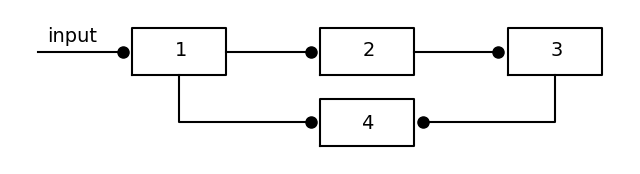

In [71]:
# four cell E net

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 2))   

plt.plot([0,0.9],[0,0],'k')
plt.plot(0.9,0,'ko',markersize=8)
plt.text(.1,.1,'input', fontsize=14)
plt.plot([1,1,2,2,1],[-0.25, 0.25, 0.25, -0.25, -0.25],'k')
plt.text(1.45,-.05,'1',fontsize=14)

plt.plot([2,2.9],[0,0],'k')
plt.plot(2.9,0,'ko',markersize=8)
plt.plot([3,3,4,4,3],[-0.25, 0.25, 0.25, -0.25, -0.25],'k')
plt.text(3.45,-.05,'2',fontsize=14)

plt.plot([4,4.9],[0,0],'k')
plt.plot(4.9,0,'ko',markersize=8)
plt.plot([5,5,6,6,5],[-0.25, 0.25, 0.25, -0.25, -0.25],'k')
plt.text(5.45,-.05,'3',fontsize=14)

plt.plot([3,3,4,4,3],[-1, -.5, -.5, -1, -1],'k')
plt.text(3.45,-.82,'4',fontsize=14)

plt.plot([1.5,1.5,2.9],[-.25,-.75,-.75],'k')
plt.plot(2.9,-.75,'ko',markersize=8)

plt.plot([5.5,5.5,4.1],[-.25,-.75,-.75],'k')
plt.plot(4.1,-.75,'ko',markersize=8)

plt.axis('equal')
plt.axis('off');

\begin{myfig}\label{fig:4cell} A four-cell E-net.\end{myfig}

We excite cell 1 every $40$ ms.
This activity propagates quickly to fire cells 2 and 4 and eventually cell 3. As 1 fires 4
we expect this weight, $W_{4,1}$, to increase, and as 3 does not fire 4 we expect $W_{4,3}$ to decrease.
To do this, when a cell fires we potentiate the weights from  presynaptic cells that have
recently fired and depress the weights  to postsynaptic cells that have recently fired. We quantify
*recent* by adopting a scheme that is in line with observations that the degree of both potentiation and depression decays
exponentially with the interval between the pre- and post-synaptic spikes, as in the figure below. 

<img src="../../BiPooSTDP.jpg" style="height:400px" />

\begin{myfig}\label{fig:bipoo} Relative weight change as a function $\tilde t\equiv t_{post}-t_{pre}$, Bi and Poo.\end{myfig}

This data suggests potentiation of the form
$A_P\exp(-\tilde t/\tau_P)$ when pre precedes post, i.e., when $\tilde t>0$, and depression of the form
$A_D\exp(\tilde t/\tau_D)$ when post precedes pre, i.e., when $\tildet<0$.

As a concrete example, we denote by $T_1$ and $T_3$ the most recent times at which cells one and three fired, respectively. If cell 2 is the next to fire, at time $T_2$, we update the associated conductances via

\begin{equation}\label{eq:hebbinc}
 \eqalign{
  W_{2,1}(T_2^+) &= W_{2,1}(T_2^-) + A_P\exp((T_1-T_2)/\tau_P) \cr
  W_{3,2}(T_2^+) &= W_{3,2}(T_2^-) - A_D\exp((T_3-T_2)/\tau_D). \cr}
\end{equation}

When called repeatedly these increments may lead to runaway weight loss and gain. There are 
a number of remedies for this. The most simple is to return to zero any weights that tend
negative and to return to $W_{max}$ all weights that exceed this specified maximum. A
smoother way of enforcing these bounds is to replace (\ref{eq:hebbinc}) with

\begin{equation}\label{eq:hebbinc2}
\eqalign{
   W_{2,1}(T_2^+) &= W_{2,1}(T_2^-) + A_P\exp((T_1-T_2)/\tau_P)(W_{max}-W_{2,1}(T_2^-)) \cr
  W_{3,2}(T_2^+) &= W_{3,2}(T_2^-) - A_D\exp((T_3-T_2)/\tau_D)W_{3,2}(T_2^-). \cr}
\end{equation}

Another advantage of this procedure is that now the maximum adjustments, $A_P$ and $A_D$, are dimensionless. 

Regarding the implementation of these general rules, if our marching scheme determines that cell $k$ fires in the interval $(jdt,(j+1)dt)$ we potentiate its presynaptic weights and depress its postsynaptic weights via

\begin{equation}\label{eq:STDPimp}
\eqalign{
  W^{j+1}_{k,k_{pre}} &= W^j_{k,k_{pre}} + A_P\exp((T_{k_{pre}}-(j+1)dt)/\tau_P)
         (W_{max}-W^j_{k,k_{pre}}) \cr
  W^{j+1}_{k_{post},k} &= W^j_{k_{post},k} - A_D\exp((T_{k_{post}}-(j+1)dt)/\tau_D)
         W^j_{k_{post},k}. \cr}
\end{equation}

We have coded these rules for the four-cell net, with

\begin{equation}\label{eq:hebb4p1}
  A_P=A_D=0.3 \hskip 0.25in \hbox{and} \hskip 0.25in \tau_P=\tau_D=10\ \text{ms}
\end{equation}

and initial weights

\begin{equation}\label{eq:hebb4p2}
W_{2,1}=W_{3,2}=W_{4,1}=0.75 \hskip 0.25in \hbox{and} \hskip 0.25in W_{4,3}=0.7\ \text{mSms/cm$^2$},
\end{equation}

and illustrate our findings in Figure \ref{fig:fourcell}.

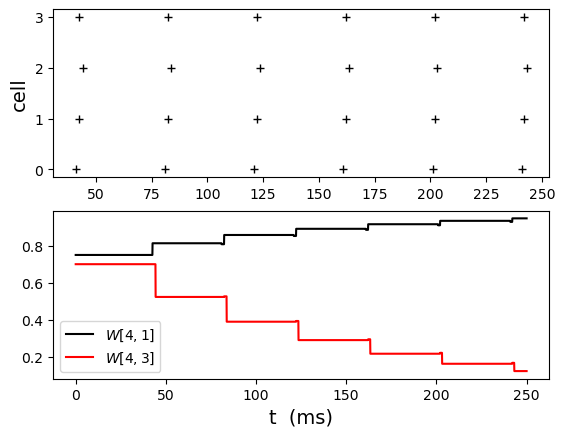

In [1]:
# fourcell plastic

import numpy as np
import matplotlib.pyplot as plt
import math

fig, (ax1, ax2) = plt.subplots(2, 1)

Tfin = 250
dt = 0.1
P =40

Nt = math.ceil(Tfin/dt)
w41 = np.zeros(Nt)  
w43 = np.zeros(Nt)

tauE = 2 
gL = 0.3 
VL = -68 
Cm = 1 
Wmax = 1

WEE = np.array([[0, 0, 0, 0],
       [0.75, 0, 0, 0],
       [0, 0.75, 0, 0],
       [0.75, 0, 0.7, 0]])

w41[0] = WEE[3,0]  
w43[0] = WEE[3,2]

tauP = 10 
tauD =  10
AP =  0.3 
AD = 0.3

pre = []
post = []
for i in range(4):
    pre.append(np.where(WEE[i,:]))  # list of presynaptic indicies
    post.append(np.where(WEE[:,i]))  # list of postsynaptic indicies

aE = (2*tauE-dt)/(2*tauE+dt)  
bE = 2/(2*tauE+dt)

tref = 3 
Vthr = -50 
Vres = -70

gE = np.zeros(4) 
VE = VL*np.ones(4) 

spE = np.zeros(4) 
TE = -500*np.ones(4)

a = 2*Cm/dt 
b = 2*gL*VL 
c = a + gL

for j in range(1,Nt):

    t = j*dt

    spin = (t/P==round(t/P))

    gEo = gE
    gE = aE*gE + bE*(WEE@spE + spin*np.array([1, 0, 0, 0]))

    VE = ( (a - (gL + gEo))*VE + b) /  (c + gE)

    refE = np.where( t-TE < tref )
    VE[refE] = Vres

    spE = (VE>Vthr)

    if sum(spE)>0:

        fspE = np.where(spE>0)[0]
        TE[fspE] = t
        VE[fspE] = Vres
        
        for ind in fspE:   # cell ind has spiked
                     
            ax1.plot(t, ind,'k+')

            ipre = pre[ind] # cells presynaptic to cell ind

            if ipre:    # potentiate presyn weights

                Deltat = TE[ipre] - t
                dWP = AP*np.exp(Deltat/tauP)
                WEE[ind,ipre] = dWP + WEE[ind,ipre]*(1 - dWP)

            ipost = post[ind]

            if ipost:   # cells postsynaptic to cell ind

                Deltat = TE[ipost] - t    # depress postsyn weights
                dWD = AD*np.exp(Deltat/tauD)
                WEE[ipost,ind] = WEE[ipost,ind]*(Wmax - dWD)
            
    w41[j] = WEE[3,0]  
    w43[j] = WEE[3,2]

ax1.set_ylabel('cell',fontsize=14)

t = np.linspace(0,Tfin,Nt)
ax2.plot(t,w41,'k')
ax2.plot(t,w43,'r')
ax2.legend(['$W[4,1]$','$W[4,3]$'])  #,'location','SW')
ax2.set_xlabel('t  (ms)',fontsize=14);

\begin{myfig}\label{fig:fourcell} Spike (top) and weight (bottom) evolution via STDP
in the 4-cell net parametrized by 
\Eqref{hebb4p1}--\Eqref{hebb4p2}. We see indeed that the direct
connection, $W_{4,1}$, is 
strengthened (up to $W_{max}=1$) while the indirect connection, $W_{4,3}$, is
diminished. \end{myfig}

We next apply this learning rule on E-to-E connections of the large net studied 
in Figure \ref{fig:EInet}.  We suppose

\begin{equation*}
  \tau_E=2, \ \tau_I=1,\ \tau_P = 5,\ \tau_D =  5\ \text{ms},\ A_P =
0.1,\ A_D = 0.3, \ W_{EE,max} = 0.2\ \text{mSms/cm$^2$},
\end{equation*}

and as above drive the first $20\%$ of the E-cells with the same spike pattern with period,
$P=100$. We permit STDP to act on the E-to-E connection and arrive at the new weights in
\fig\figref{EInetHa}.

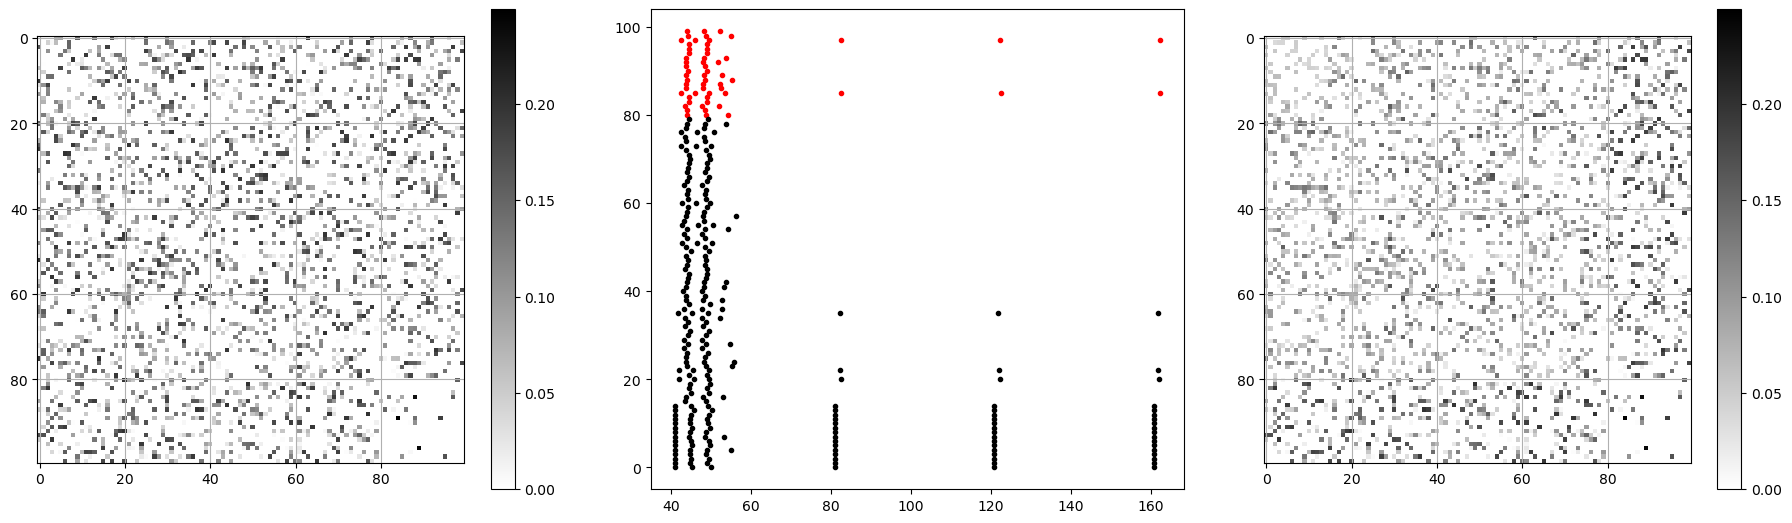

In [35]:
# EInetH

import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import random_array 
import networkx as nx

fig, (ax1, ax2, ax3) = plt.subplots(1,3)
plt.subplots_adjust(right=3, left=0.25, wspace=0.15, top=1, bottom=0) 

EInet = {"NE":80, "NI":20, "denEE":0.25, "denEI":0.25, "denIE":0.25, "denII":0.05}

rng = np.random.default_rng(42)  # make it reproducible

sparse_matrix = random_array((EInet["NE"], EInet["NE"]), density=EInet["denEE"], format='csr') #, random_state=rng) 
WEE = sparse_matrix.toarray()/5
for r in range(EInet["NE"]):
    WEE[r,r] = 0.0                # remove autapses
    
sparse_matrix = random_array((EInet["NI"], EInet["NE"]), density=EInet["denEI"], format='csr') #, random_state=rng) 
WEI = sparse_matrix.toarray()/5

sparse_matrix = random_array((EInet["NE"], EInet["NI"]), density=EInet["denIE"], format='csr') #, random_state=rng) 
WIE = sparse_matrix.toarray()/5

sparse_matrix = random_array((EInet["NI"], EInet["NI"]), density=EInet["denII"], format='csr') #, random_state=rng) 
WII = sparse_matrix.toarray()/4
for r in range(EInet["NI"]):
    WII[r,r] = 0.0                # remove autapses
    
W = np.block([[WEE, WIE],[WEI, WII]])    # assemble for visualization
im1 = ax1.imshow(W, cmap='gray_r')
fig.colorbar(im1, ax=ax1)
ax1.grid('on')

Tfin = 200
dt = 0.05
P = 40

Nt = math.ceil(Tfin/dt)

tauE = 2 
VsynE = 0
tauI = 1 
VsynI = -70

gL = 0.3 
VL = -68 
Cm = 1

WinEE = np.zeros(EInet["NE"])                        
WinEE[0:15] = 1        # drive 1st 16 E cells

aE = (2*tauE-dt)/(2*tauE+dt) 
bE = 2/(2*tauE+dt)

aI = (2*tauI-dt)/(2*tauI+dt) 
bI = 2/(2*tauI+dt)

tref = 3 
Vthr = -50 
Vres = -70

gEE = np.zeros(EInet["NE"]) 
VE = VL*np.ones(EInet["NE"]) 

gII = np.zeros(EInet["NI"]) 
VI = VL*np.ones(EInet["NI"]) 

gEI = np.zeros(EInet["NI"]) 

gIE = np.zeros(EInet["NE"]) 

spE = np.zeros(EInet["NE"]) 
TE = -10*np.ones(EInet["NE"]) 

spI = np.zeros(EInet["NI"])
TI = -10*np.ones(EInet["NI"]) 

a = 2*Cm/dt 
b = 2*gL*VL 
c = a + gL

Wmax = 0.2
tauP = 5 
tauD = 5
AP =  0.1 
AD = 0.3

pre = []
post = []
for i in range(EInet["NE"]):
    pre.append(np.where(WEE[i,:]))  # list of presynaptic indicies
    post.append(np.where(WEE[:,i]))  # list of postsynaptic indicies


for j in range(1,Nt):

    t = j*dt

    spin = (t/P==round(t/P))

    gEEo = gEE
    gEE = aE*gEE + bE*(WEE@spE + spin*WinEE)

    gEIo = gEI
    gEI = aE*gEI + bE*WEI@spE

    gIEo = gIE
    gIE = aI*gIE + bI*WIE@spI 

    gIIo = gII
    gII = aI*gII + bI*WII@spI

    VE = ( (a - (gL + gEEo + gIEo))*VE + b + (gIE+gIEo)*VsynI ) /  (c + gEE + gIE)

    VI = ( (a - (gL + gIIo + gEIo))*VI + b + (gII+gIIo)*VsynI ) /  (c + gII + gEI)

    refE = np.where( t-TE < tref )
    VE[refE] = Vres

    spE = (VE>Vthr)

    if sum(spE)>0:
        fspE = np.where(spE>0)[0]
        TE[fspE] = t
        VE[fspE] = Vres
        
        for ind in fspE:
            
            ax2.plot(t,ind,'k.')

            ipre = pre[ind]

            if ipre:    # potentiate presyn weights

                Deltat = TE[ipre] - t
                dWP = AP*np.exp(Deltat/tauP)
                WEE[ind,ipre] = Wmax*dWP + WEE[ind,ipre]*(1 - dWP)

            ipost = post[ind]

            if ipost:

                Deltat = TE[ipost] - t       # depress postsyn weights
                dWD = AD*np.exp(Deltat/tauD)
                WEE[ipost,ind] = WEE[ipost,ind]*(1 - dWD)

    refI = np.where( t-TI < tref )
    VI[refI] = Vres

    spI = (VI>Vthr)

    if sum(spI)>0:
        fspI = np.where(spI>0)[0]
        TI[fspI] = t
        VI[fspI] = Vres
        for ind in fspI:
            ax2.plot(t,EInet["NE"]+ind,'r.')

#Waft = [WEE WIE WEI WII]

W = np.block([[WEE, WIE],[WEI, WII]])    # assemble for visualization
im1 = ax3.imshow(W, cmap='gray_r')
fig.colorbar(im1, ax=ax3)
ax3.grid('on')

'''
    winc = 600*10

    if mod(j,winc) == 0

       figure(3)
       [iw,jw,sw] = find(WEE)
       nbin = 20
       hw = hist(sw,nbin)
       wax = linspace(0,Wmax,nbin)
       plot3(wax,t*ones(nbin,1),hw/length(sw),'k')
       hold on

    end
'''
'''
figure(2)
hold off
box off
xlim([10 590])
ylim([0.5 Ntot+0.5])
set(gca,'tickdir','out')
xlabel('t  (ms)','fontsize',14)
ylabel('cell','fontsize',14)

figure(3)
hold off
view(27.5,42)
xlabel('weight','fontsize',14)
ylabel('time','fontsize',14)
zlabel('fraction','fontsize',14)

figure(4)
imagesc(Waft)
colormap(1-gray)
colorbar
hold on
plot([0 Ntot+0.5],[N.E+0.5 N.E+0.5],'r')
plot([N.E+0.5 N.E+0.5],[0 Ntot+0.5],'r')
axis square
set(gca,'xtick',get(gca,'ytick'))
set(gca,'xaxislocation','top')
grid
set(gca,'tickdir','out')
hold off
''';



\begin{myfig}\label{fig:EInetHa}
Initial weights (left) and spikes (center) and final weights after 200 milliseconds of STDP.
\end{myfig}


These gray-scale weight plots of \figs\figref{EInet} and
\fig\figref{EInetHa} are  
not the best means of tracking weight shifts over time.
In \fig\figref{EInetHb} we report instead the running weight distribution.



\centerline{\includegraphics{chapters/ch30Networks/Nov16Whist.eps}}
\figlabel{EInetHb}
\fig\figref{EInetHb}. Running histogram of E-to-E synaptic weights for the network of
\fig\figref{EInet}. As in the four cell example we see that most weights shift to the
two extremes over time. ({ EInetH.m})



To the question, *What has the network learned?* we answer that it has learned to associate the 
*input pattern,* comprised of	simultaneous firing of cells
$$
  {\rm in} \equiv \{1:16\},
$$
with the output pattern of \fig\figref{EInetHa}B, i.e., the firing of cells
$$
  {\rm out} \equiv \{22:24,26,31:33,39,41,42,44,48,49,51,55,64,66,77:79\}
$$ 
within the next few milliseconds. In order to test the strength of this association we measure the 
learned network's ability to complete incomplete input. 
In particular, we systematically drop input spikes and count the
average number of dropped output spikes. We implement this test  and find that 
dropping 1 input spike produces no loss in output fidelity.
Dropping 2 input spikes produces an average loss of 4% of the output spikes and
dropping 3 input spikes produces an average loss of 34% of the output spikes. Each
average is computed over $16!/(d!(16-d)!)$ random trials of $d$ dropped input spikes.
We see no loss when $d=1$ and substantial loss when $d=3$. At the intermediate stage
we note that $d=2$ produces 12.5\% input error and yet our output is only off by
4\%. In that sense, STDP has endowed the random network of
\fig\figref{EInet}A with the 
power of *pattern completion.*

**Book Notes**

cd 415/svn/book415ed2/trunk
cd chapters
cd ch30Networks/
nets.tex

/www/cox/public_html/booksite/networks
does not have all the m files, most are linked to extinct elsevier site

found them in
/home/cox/415/svn/book415/networks